# For Determining Redshift

(WIP)

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as nd

import astropy.io.fits as pyfits
import astropy.units as u

import sep

import grizli
from grizli import utils
print(f'grizli version: {grizli.__version__}')

import msaexp
print(f'msaexp version: {msaexp.__version__}')

BASE_URL = 'https://s3.amazonaws.com/msaexp-nirspec/extractions/'
PATH_TO_FILE = BASE_URL + '{root}/{file}'

grizli version: 1.13.2
msaexp version: 0.9.12


In [3]:
nrs = utils.read_catalog(BASE_URL + 'nirspec_graded_v0.ecsv', format='ascii.ecsv')

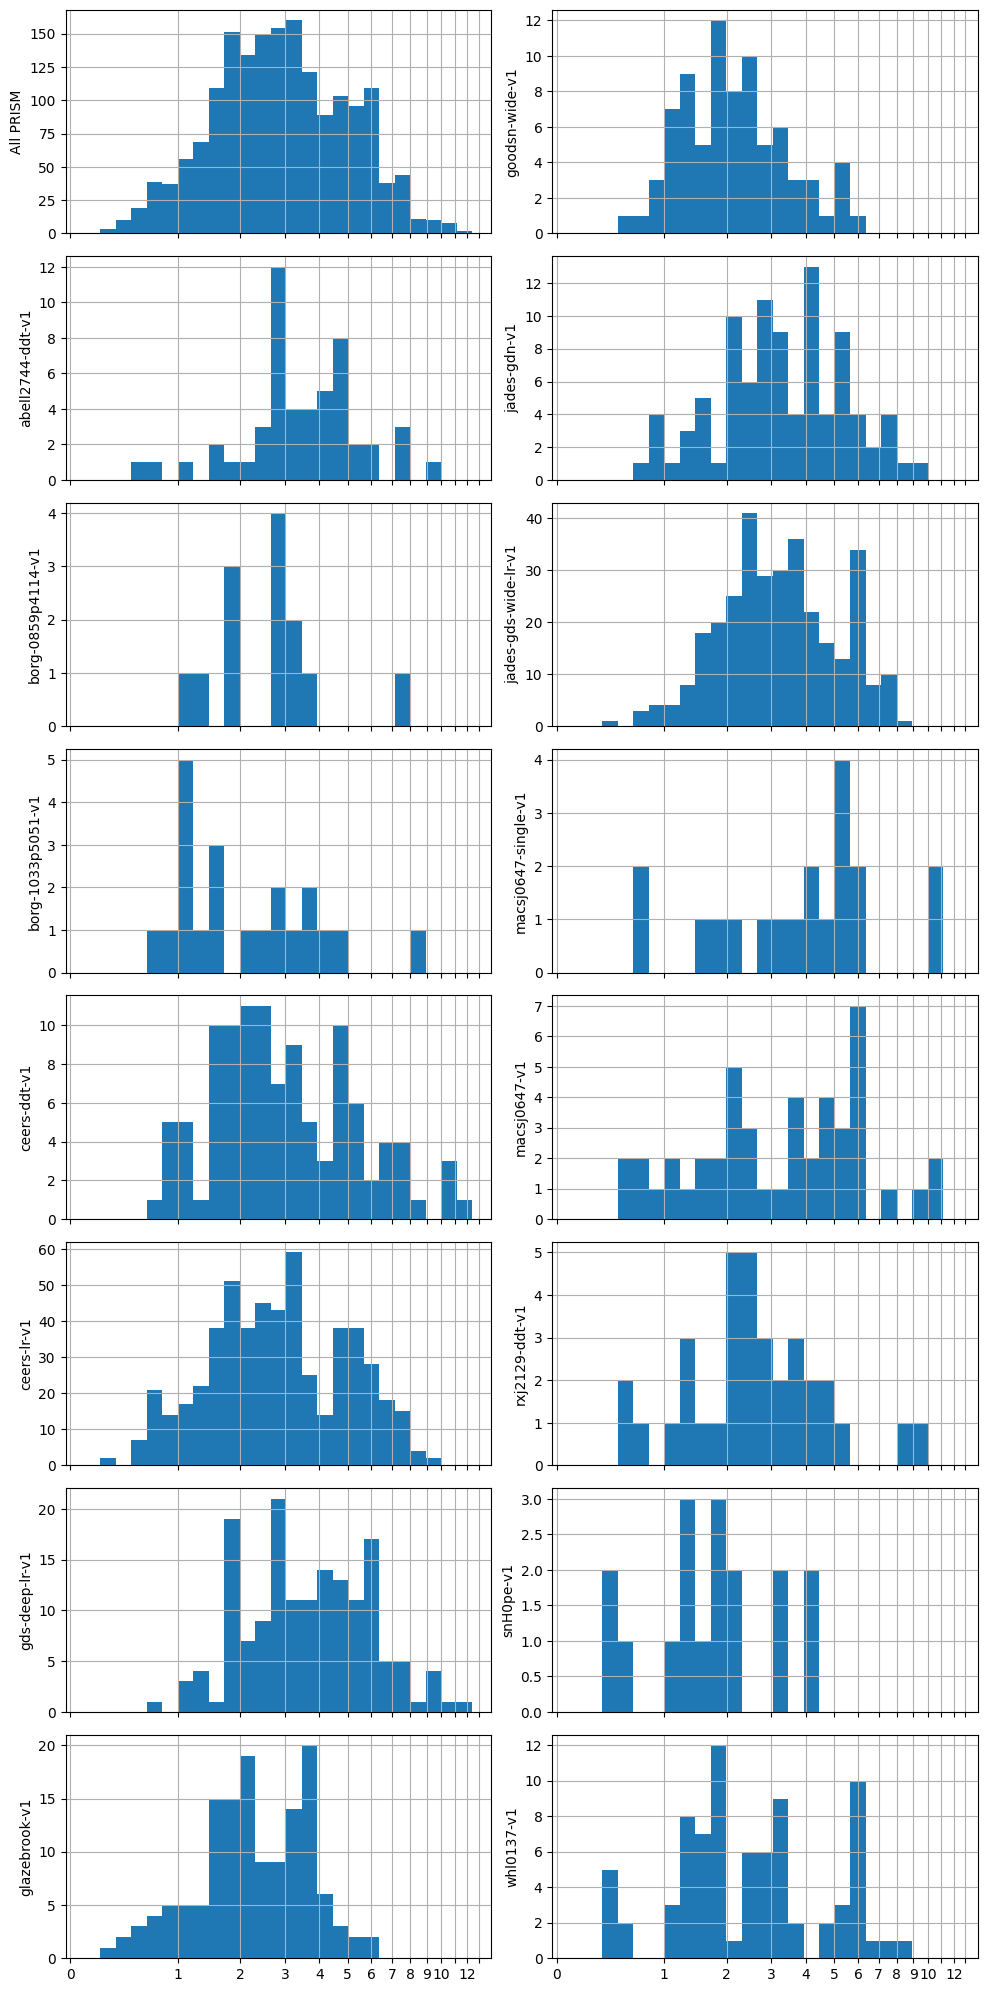

In [4]:
robust_prism = (nrs['grating'] == 'PRISM') & (nrs['grade'] == 3)

roots = utils.Unique(nrs['root'][robust_prism], verbose=False)

nx = 2
ny = int(np.ceil((len(roots) + 1) / 2))

sx = 2.5

fig, axes = plt.subplots(ny,nx,sharex=True, sharey=False, figsize=(nx*sx*2, ny*sx))

lnz = np.log(1+nrs['z'])

bins = utils.log_zgrid([0.1, 13], 0.1)

xtv = [0,1,2,3,4,5,6,7,8,9,10,11,12,13]
xtl = [0,1,2,3,4,5,6,7,8,9,10,'',12,'']

_ = axes[0][0].hist(lnz[robust_prism], bins=np.log(1+bins))
axes[0][0].set_ylabel('All PRISM')
axes[0][0].grid()

count = 0

for root in roots.values:
    count += 1
    i = count // ny
    j = count - ny*i
    
    _ = axes[j][i].hist(lnz[robust_prism][roots[root]], bins=np.log(1+bins))
    axes[j][i].set_ylabel(root)
    axes[j][i].grid()
    
axes[j][i].set_xticks(np.log(1+np.array(xtv)))
axes[j][i].set_xticklabels(xtl)

for last in range(count*1, nx*ny-1):
    count += 1
    i = count // ny
    j = count - ny*i
    
    _ = axes[j][i].axis('off')

_ = fig.tight_layout(pad=1)

In [5]:
id = '15157' # z=4.1
ymax = [0.8, 0.4, 0.8, 0.8]
xlimits = [(0.5, 5.4), (0.5, 2.2), (2.2, 2.8), (3.18, 3.6)]

is_gds = np.array([f.startswith('gds-deep') for f in nrs['file']])

src = np.array([id in f for f in nrs['file']]) & is_gds

nrs['root','file','grating','filter','z','grade'][src]

urls = [PATH_TO_FILE.format(**row) for row in nrs[src]]

z = np.mean(nrs['z'][src & (nrs['grade'] == 3)])

nrs[src]['root','file','grating','filter','z','grade']

root,file,grating,filter,z,grade
str20,str57,str5,str6,float64,int64
gds-deep-hr-v1,gds-deep-hr-v1_g395h-f290lp_1210_15157.spec.fits,G395H,F290LP,4.1486,3
gds-deep-lr-v1,gds-deep-lr-v1_prism-clear_1210_15157.spec.fits,PRISM,CLEAR,4.1499,3
gds-deep-mr-v1,gds-deep-mr-v1_g140m-f070lp_1210_15157.spec.fits,G140M,F070LP,4.2156,1
gds-deep-mr-v1,gds-deep-mr-v1_g235m-f170lp_1210_15157.spec.fits,G235M,F170LP,4.1482,3
gds-deep-mr-v1,gds-deep-mr-v1_g395m-f290lp_1210_15157.spec.fits,G395M,F290LP,4.1482,3


In [6]:
import msaexp.spectrum

In [7]:
sobj = {}
for u in urls:
    print(f'Read {u}')
    key = os.path.basename(u)
    sobj[key] = msaexp.spectrum.SpectrumSampler(u)

Read https://s3.amazonaws.com/msaexp-nirspec/extractions/gds-deep-hr-v1/gds-deep-hr-v1_g395h-f290lp_1210_15157.spec.fits


HTTPError: HTTP Error 403: Forbidden